C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== 実験設定 ===
Time step split: train<= 34, val<= 39, test>= 40
Time step を特徴に含める: False
unknown の 5.0% を train だけ illicit にする
class weights: [8.0, 1.0]
Loading txs_features...
  shape: (203769, 184)
  columns: ['txId', 'Time step', 'Local_feature_1', 'Local_feature_2', 'Local_feature_3', 'Local_feature_4', 'Local_feature_5', 'Local_feature_6', 'Local_feature_7', 'Local_feature_8'] ...

Loading txs_classes...
  shape: (203769, 2)
  columns: ['txId', 'class']
  class unique: [3 2 1]

Loading txs_edgelist...
  shape: (234355, 2)
  columns: ['txId1', 'txId2']

=== Features overview ===
    txId  Time step  Local_feature_1  Local_feature_2  Local_feature_3  \
0   3321          1        -0.169615        -0.184668        -1.201369   
1  11108          1        -0.137586        -0.184668        -1.201369   
2  51816          1        -0.170103        -0.184668        -1.201369   
3  68869          1        -0.114267        -0.184668        -1.201369   
4  89273          1         5.202107     

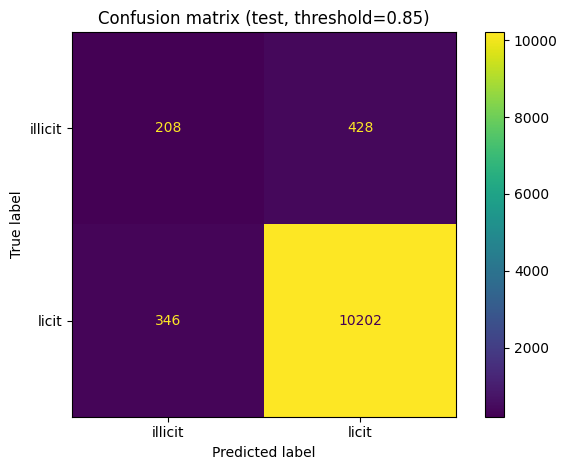


=== Classification Report (test only) ===
              precision    recall  f1-score   support

     illicit       0.38      0.33      0.35       636
       licit       0.96      0.97      0.96     10548

    accuracy                           0.93     11184
   macro avg       0.67      0.65      0.66     11184
weighted avg       0.93      0.93      0.93     11184



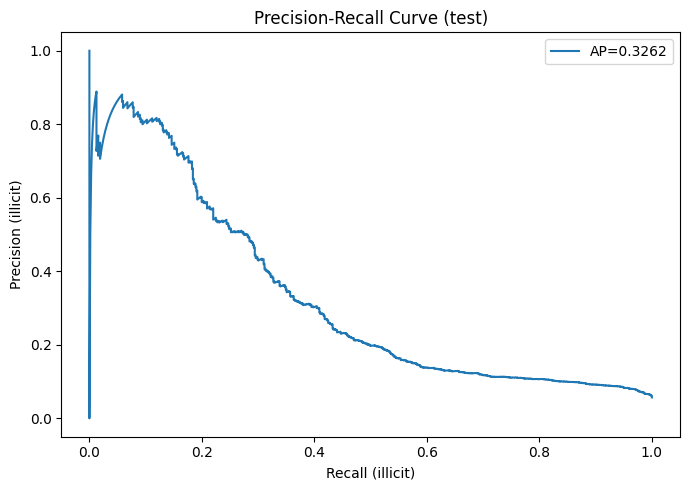

[PR curve] Average Precision (illicit): 0.3262
[t-SNE] sampled 2000/51882 labeled nodes.


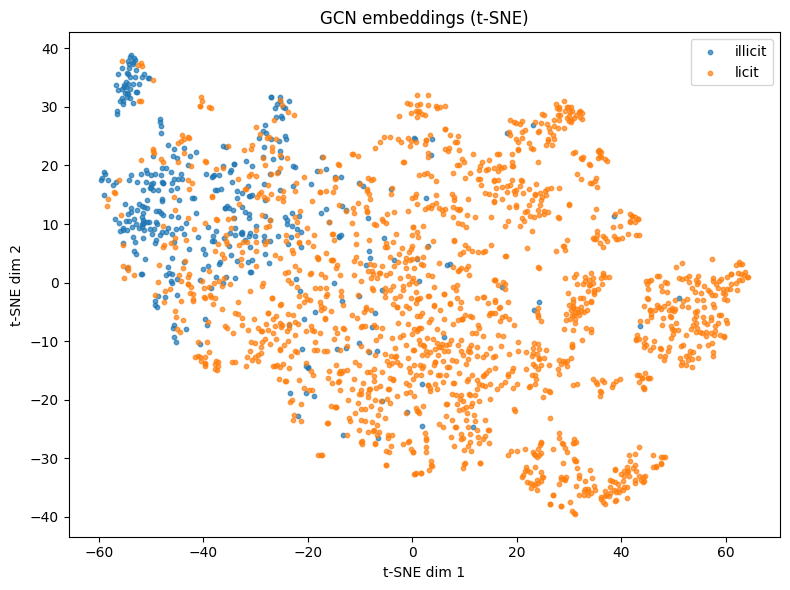

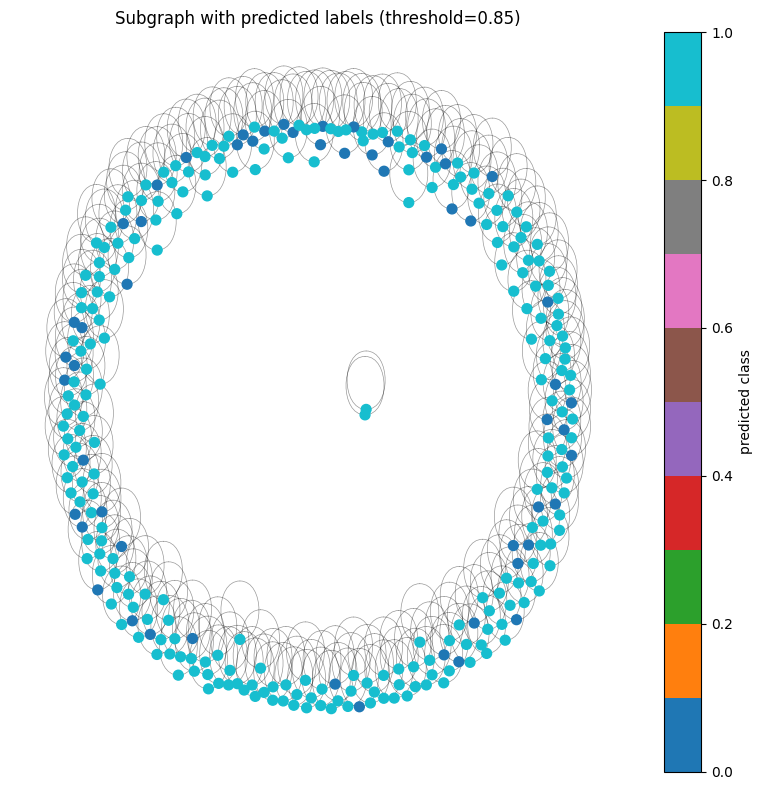


Done.


In [1]:
"""
Elliptic++ っぽいトランザクショングラフに
GNN（GCN）を適用して illicit 検出を改善する完全版スクリプト。

追加仕様
- unknown(class=3) のうち、train 範囲にあるものの 5% を
  擬似的に illicit(0) に置き換えて学習に使う
- その設定をコード先頭と途中経過ログで明示する
- 変更前 / 変更後の 3ラベル
    illicit / licit / unknown
  の件数と総数を表示する
"""

import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.utils import to_networkx, to_undirected, add_self_loops
from torch_geometric.nn import GCNConv

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
)


warnings.filterwarnings("ignore")


# ==========================
# 設定
# ==========================
TXS_FEATURES = "./transactions/txs_features.txt"
TXS_CLASSES  = "./transactions/txs_classes.txt"
TXS_EDGES    = "./transactions/txs_edgelist.txt"

TRAIN_END_STEP = 34
VAL_END_STEP   = 39

HIDDEN_DIM = 64
DROPOUT = 0.5
LR = 1e-3
WEIGHT_DECAY = 5e-4
EPOCHS = 150

# class 0 = illicit, class 1 = licit
CLASS_WEIGHTS = [8.0, 1.0]

INCLUDE_TIME_STEP_AS_FEATURE = False

TSNE_MAX_NODES = 2000
SUBGRAPH_NODES = 300

# ----------------------------------------
# unknown のうち、train 範囲にあるものだけを
# 何% illicit に擬似ラベル化するか
# 0.05 = 5%
# ----------------------------------------
UNKNOWN_TO_ILLICIT_RATIO = 0.05


# ==========================
# ユーティリティ
# ==========================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def check_files():
    for path in [TXS_FEATURES, TXS_CLASSES, TXS_EDGES]:
        if not Path(path).exists():
            raise FileNotFoundError(f"ファイルが見つかりません: {path}")


def make_time_based_masks(
    time_steps: torch.Tensor,
    labeled_mask: torch.Tensor,
    train_end_step: int,
    val_end_step: int
):
    train_mask = (time_steps <= train_end_step) & labeled_mask
    val_mask   = (time_steps > train_end_step) & (time_steps <= val_end_step) & labeled_mask
    test_mask  = (time_steps > val_end_step) & labeled_mask
    return train_mask, val_mask, test_mask


def print_split_class_counts(y_np, train_mask, val_mask, test_mask):
    print("\n[split] train class counts:")
    print(pd.Series(y_np[train_mask.numpy()]).value_counts().sort_index())

    print("\n[split] val class counts:")
    print(pd.Series(y_np[val_mask.numpy()]).value_counts().sort_index())

    print("\n[split] test class counts:")
    print(pd.Series(y_np[test_mask.numpy()]).value_counts().sort_index())


def print_label_summary(y_np, title="label summary"):
    """
    y_np:
      0  -> illicit
      1  -> licit
     -1  -> unknown
    """
    illicit_count = int((y_np == 0).sum())
    licit_count   = int((y_np == 1).sum())
    unknown_count = int((y_np == -1).sum())
    total_count   = len(y_np)

    print(f"\n=== {title} ===")
    print(f"illicit : {illicit_count}")
    print(f"licit   : {licit_count}")
    print(f"unknown : {unknown_count}")
    print(f"total   : {total_count}")


def print_label_diff(before_y, after_y):
    before_illicit = int((before_y == 0).sum())
    before_licit   = int((before_y == 1).sum())
    before_unknown = int((before_y == -1).sum())

    after_illicit = int((after_y == 0).sum())
    after_licit   = int((after_y == 1).sum())
    after_unknown = int((after_y == -1).sum())

    print("\n=== ラベル件数の増減 ===")
    print(f"illicit : {before_illicit} -> {after_illicit}  (diff {after_illicit - before_illicit:+d})")
    print(f"licit   : {before_licit} -> {after_licit}  (diff {after_licit - before_licit:+d})")
    print(f"unknown : {before_unknown} -> {after_unknown}  (diff {after_unknown - before_unknown:+d})")
    print(f"total   : {len(before_y)} -> {len(after_y)}  (diff {len(after_y) - len(before_y):+d})")


def inject_unknown_as_illicit_by_ratio(
    y_np: np.ndarray,
    time_steps_np: np.ndarray,
    train_end_step: int,
    ratio: float = 0.05,
    seed: int = 42
):
    """
    train 範囲の unknown(-1) の一部を illicit(0) に変更する
    """
    rng = np.random.default_rng(seed)

    train_unknown_idx = np.where(
        (time_steps_np <= train_end_step) & (y_np == -1)
    )[0]

    n_unknown = len(train_unknown_idx)
    n_pick = int(n_unknown * ratio)

    y_new = y_np.copy()

    if n_unknown == 0 or n_pick == 0:
        print(
            f"[inject] train 内 unknown の {ratio:.1%} を illicit に変更: "
            f"0/{n_unknown}"
        )
        return y_new, np.array([], dtype=np.int64)

    chosen = rng.choice(train_unknown_idx, size=n_pick, replace=False)
    y_new[chosen] = 0

    print(
        f"[inject] train 内 unknown の {ratio:.1%} を illicit に変更: "
        f"{n_pick}/{n_unknown}"
    )
    return y_new, np.sort(chosen)


# ==========================
# データ読み込み
# ==========================
def load_raw_data():
    print("Loading txs_features...")
    df_features = pd.read_csv(TXS_FEATURES)
    print("  shape:", df_features.shape)
    print("  columns:", list(df_features.columns[:10]), "...")

    print("\nLoading txs_classes...")
    df_classes = pd.read_csv(TXS_CLASSES)
    print("  shape:", df_classes.shape)
    print("  columns:", list(df_classes.columns))
    if "class" in df_classes.columns:
        print("  class unique:", df_classes["class"].unique())

    print("\nLoading txs_edgelist...")
    df_edges = pd.read_csv(TXS_EDGES)
    print("  shape:", df_edges.shape)
    print("  columns:", list(df_edges.columns))

    print("\n=== Features overview ===")
    print(df_features.head())
    print("missing values (total):", int(df_features.isnull().sum().sum()))

    print("\n=== Classes overview ===")
    print(df_classes["class"].value_counts(dropna=False))

    print("\n=== Edges overview ===")
    print(df_edges.head())
    print("duplicate edges:", int(df_edges.duplicated().sum()))

    return df_features, df_classes, df_edges


# ==========================
# PyG Data 構築
# ==========================
def build_pyg_data(
    df_features: pd.DataFrame,
    df_classes: pd.DataFrame,
    df_edges: pd.DataFrame,
    train_end_step: int,
    val_end_step: int,
    include_time_step_as_feature: bool = False,
    unknown_to_illicit_ratio: float = 0.05,
    seed: int = 42
):
    id_col_feat = df_features.columns[0]
    print(f"\n[build_pyg_data] using '{id_col_feat}' as node id column.")

    if "Time step" not in df_features.columns:
        raise ValueError("df_features に 'Time step' 列がありません。")

    # ---- Time step ----
    time_steps_np = pd.to_numeric(
        df_features["Time step"], errors="coerce"
    ).fillna(-1).to_numpy(dtype=np.int64)
    time_steps = torch.tensor(time_steps_np, dtype=torch.long)

    print("[build_pyg_data] time step min/max:",
          int(time_steps.min().item()), int(time_steps.max().item()))

    # ---- 特徴量 ----
    feature_cols = [c for c in df_features.columns if c != id_col_feat]
    if not include_time_step_as_feature:
        feature_cols = [c for c in feature_cols if c != "Time step"]

    x_df = df_features[feature_cols].copy()
    x_df = x_df.apply(pd.to_numeric, errors="coerce")

    nan_total_before = int(x_df.isna().sum().sum())
    inf_total_before = int(np.isinf(x_df.to_numpy(dtype=np.float64)).sum())
    print("[build_pyg_data] NaN in features before fill:", nan_total_before)
    print("[build_pyg_data] Inf in features before replace:", inf_total_before)

    x_df = x_df.replace([np.inf, -np.inf], np.nan)
    x_df = x_df.fillna(0.0)

    # ---- ラベル ----
    if "class" not in df_classes.columns:
        raise ValueError("df_classes に 'class' 列がありません。")

    if id_col_feat in df_classes.columns:
        id_col_cls = id_col_feat
    else:
        id_col_cls = df_classes.columns[0]
        print(f"[build_pyg_data] WARNING: using '{id_col_cls}' as class id column.")

    node_ids = df_features[id_col_feat].astype(int).values
    id2idx = {int(nid): i for i, nid in enumerate(node_ids)}

    cls_series = (
        df_classes
        .set_index(id_col_cls)["class"]
        .reindex(node_ids)
    )

    # 1 -> illicit -> 0
    # 2 -> licit   -> 1
    # 3 -> unknown -> -1
    label_map = {1: 0, 2: 1, 3: -1}
    y_np_original = cls_series.map(label_map).fillna(-1).to_numpy(dtype=np.int64)

    print_label_summary(y_np_original, title="変更前のラベル件数")

    # train 内 unknown の一部を illicit に変更
    y_np, injected_idx = inject_unknown_as_illicit_by_ratio(
        y_np=y_np_original,
        time_steps_np=time_steps_np,
        train_end_step=train_end_step,
        ratio=unknown_to_illicit_ratio,
        seed=seed
    )

    print_label_summary(y_np, title="変更後のラベル件数")
    print_label_diff(y_np_original, y_np)

    y = torch.tensor(y_np, dtype=torch.long)
    labeled_mask = y >= 0

    print("[build_pyg_data] labeled nodes:", int(labeled_mask.sum()), "/", len(y_np))

    # ---- time-based mask ----
    train_mask, val_mask, test_mask = make_time_based_masks(
        time_steps=time_steps,
        labeled_mask=labeled_mask,
        train_end_step=train_end_step,
        val_end_step=val_end_step
    )

    print("[build_pyg_data] split by time step:")
    print(f"  train: time_step <= {train_end_step}")
    print(f"  val  : {train_end_step + 1} <= time_step <= {val_end_step}")
    print(f"  test : time_step >= {val_end_step + 1}")

    print("[build_pyg_data] train/val/test labeled counts:",
          int(train_mask.sum()), int(val_mask.sum()), int(test_mask.sum()))

    print_split_class_counts(y_np, train_mask, val_mask, test_mask)

    print(f"\n[build_pyg_data] injected pseudo-illicit nodes: {len(injected_idx)}")
    if len(injected_idx) > 0:
        print("[build_pyg_data] first 10 injected node indices:", injected_idx[:10])

    # ---- 標準化: train のみで fit ----
    scaler = StandardScaler()
    x_np = x_df.to_numpy(dtype=np.float32)

    train_idx_np = train_mask.numpy()
    scaler.fit(x_np[train_idx_np])

    x_np = scaler.transform(x_np).astype(np.float32)
    x_np = np.nan_to_num(x_np, nan=0.0, posinf=0.0, neginf=0.0)
    x_np = np.clip(x_np, -10.0, 10.0)

    x = torch.tensor(x_np, dtype=torch.float)

    print("[build_pyg_data] x shape:", tuple(x.shape))
    print("[build_pyg_data] torch.isnan(x).any():", torch.isnan(x).any().item())
    print("[build_pyg_data] torch.isinf(x).any():", torch.isinf(x).any().item())

    # ---- エッジ ----
    edge_cols = list(df_edges.columns[:2])
    src_raw = df_edges[edge_cols[0]].values
    dst_raw = df_edges[edge_cols[1]].values

    src_idx = []
    dst_idx = []
    missing_edges = 0

    for u, v in zip(src_raw, dst_raw):
        u = int(u)
        v = int(v)
        if u in id2idx and v in id2idx:
            src_idx.append(id2idx[u])
            dst_idx.append(id2idx[v])
        else:
            missing_edges += 1

    edge_index = torch.tensor([src_idx, dst_idx], dtype=torch.long)
    edge_index = to_undirected(edge_index, num_nodes=len(node_ids))
    edge_index, _ = add_self_loops(edge_index, num_nodes=len(node_ids))

    print("[build_pyg_data] edge_index shape:", tuple(edge_index.shape))
    print("[build_pyg_data] skipped edges with unknown nodes:", missing_edges)

    data = Data(x=x, edge_index=edge_index, y=y)
    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask
    data.labeled_mask = labeled_mask
    data.time_steps = time_steps
    data.injected_idx = torch.tensor(injected_idx, dtype=torch.long)

    classes = ["illicit", "licit"]
    return data, classes


# ==========================
# モデル
# ==========================
class GCN(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float = 0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index, return_embeddings=False):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        embeddings = x
        logits = self.lin(x)

        if return_embeddings:
            return logits, embeddings
        return logits


# ==========================
# 推論・評価
# ==========================
def get_logits_and_probs(model: nn.Module, data: Data):
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        logits = model(data.x.to(device), data.edge_index.to(device))
        probs = torch.softmax(logits, dim=-1).cpu()
    return logits.cpu(), probs


def predict_with_threshold(probs: torch.Tensor, threshold: float = 0.5):
    illicit_prob = probs[:, 0]
    pred = torch.where(
        illicit_prob >= threshold,
        torch.tensor(0),
        torch.tensor(1)
    )
    return pred.long()


def evaluate_with_threshold(model: nn.Module, data: Data, split: str, threshold: float = 0.5):
    if split == "train":
        mask = data.train_mask.cpu()
    elif split == "val":
        mask = data.val_mask.cpu()
    elif split == "test":
        mask = data.test_mask.cpu()
    else:
        raise ValueError("split must be 'train', 'val', or 'test'")

    if int(mask.sum()) == 0:
        return None

    logits, probs = get_logits_and_probs(model, data)
    pred = predict_with_threshold(probs, threshold=threshold)
    y_true = data.y.cpu()

    y_true_masked = y_true[mask].numpy()
    y_pred_masked = pred[mask].numpy()

    result = {
        "threshold": threshold,
        "accuracy": float((y_true[mask] == pred[mask]).float().mean().item()),
        "illicit_precision": float(precision_score(y_true_masked, y_pred_masked, pos_label=0, zero_division=0)),
        "illicit_recall": float(recall_score(y_true_masked, y_pred_masked, pos_label=0, zero_division=0)),
        "illicit_f1": float(f1_score(y_true_masked, y_pred_masked, pos_label=0, zero_division=0)),
    }
    return result


def search_best_threshold(model: nn.Module, data: Data, threshold_grid=None):
    if threshold_grid is None:
        threshold_grid = np.arange(0.05, 0.96, 0.05)

    best = None
    rows = []

    for th in threshold_grid:
        metrics = evaluate_with_threshold(model, data, split="val", threshold=float(th))
        rows.append(metrics)

        if best is None:
            best = metrics
        else:
            if (metrics["illicit_f1"] > best["illicit_f1"]) or (
                metrics["illicit_f1"] == best["illicit_f1"] and
                metrics["illicit_recall"] > best["illicit_recall"]
            ):
                best = metrics

    df_scores = pd.DataFrame(rows)
    print("\n=== Threshold search on validation ===")
    print(df_scores.to_string(index=False))

    print("\n[best threshold on val]")
    print(best)
    return best["threshold"], df_scores


# ==========================
# 学習
# ==========================
def train_gcn(
    data: Data,
    num_classes: int,
    hidden_dim: int = 64,
    dropout: float = 0.5,
    lr: float = 1e-3,
    weight_decay: float = 5e-4,
    epochs: int = 100,
    class_weights=(8.0, 1.0)
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("[train_gcn] device:", device)
    print("[train_gcn] data.x has NaN:", torch.isnan(data.x).any().item())
    print("[train_gcn] data.x has Inf:", torch.isinf(data.x).any().item())
    print("[train_gcn] unique y:", torch.unique(data.y))
    print("[train_gcn] train labeled count:", int(data.train_mask.sum()))

    model = GCN(
        in_dim=data.num_node_features,
        hidden_dim=hidden_dim,
        out_dim=num_classes,
        dropout=dropout
    ).to(device)

    cw = torch.tensor(class_weights, dtype=torch.float, device=device)
    print("[train_gcn] class weights:", cw.tolist())

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    data = data.to(device)

    best_state = None
    best_val_f1 = -1.0
    best_val_recall = -1.0

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(data.x, data.edge_index)
        loss = F.cross_entropy(
            logits[data.train_mask],
            data.y[data.train_mask],
            weight=cw
        )

        if torch.isnan(loss):
            raise ValueError("loss が NaN になりました。特徴量 x を確認してください。")

        loss.backward()
        optimizer.step()

        if epoch == 1 or epoch % 10 == 0:
            val_metrics = evaluate_with_threshold(model, data.cpu(), split="val", threshold=0.5)
            train_metrics = evaluate_with_threshold(model, data.cpu(), split="train", threshold=0.5)

            print(
                f"[Epoch {epoch:03d}] "
                f"loss={loss.item():.4f} | "
                f"train_acc={train_metrics['accuracy']:.4f} "
                f"train_illicit_recall={train_metrics['illicit_recall']:.4f} "
                f"train_illicit_f1={train_metrics['illicit_f1']:.4f} | "
                f"val_acc={val_metrics['accuracy']:.4f} "
                f"val_illicit_recall={val_metrics['illicit_recall']:.4f} "
                f"val_illicit_f1={val_metrics['illicit_f1']:.4f}"
            )

            if (
                val_metrics["illicit_f1"] > best_val_f1
                or (
                    val_metrics["illicit_f1"] == best_val_f1
                    and val_metrics["illicit_recall"] > best_val_recall
                )
            ):
                best_val_f1 = val_metrics["illicit_f1"]
                best_val_recall = val_metrics["illicit_recall"]
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
        model = model.to(device)

    return model, data.cpu()


# ==========================
# 可視化
# ==========================
def inspect_prediction_distribution(model: nn.Module, data: Data, threshold: float):
    logits, probs = get_logits_and_probs(model, data)
    pred = predict_with_threshold(probs, threshold=threshold)

    mask = data.test_mask.cpu()
    print("\n=== Prediction distribution on test ===")
    print("threshold:", threshold)

    print("\npred counts:")
    print(pd.Series(pred[mask].numpy()).value_counts().sort_index())

    print("\ntrue counts:")
    print(pd.Series(data.y.cpu()[mask].numpy()).value_counts().sort_index())


def visualize_confusion_matrix(model: nn.Module, data: Data, classes=None, threshold: float = 0.5):
    logits, probs = get_logits_and_probs(model, data)
    pred = predict_with_threshold(probs, threshold=threshold)

    mask = data.test_mask.cpu().numpy()
    y_true = data.y.cpu().numpy()[mask]
    y_pred = pred.cpu().numpy()[mask]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(classes))) if classes is not None else None
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes if classes is not None else None
    )
    disp.plot(values_format="d")
    plt.title(f"Confusion matrix (test, threshold={threshold:.2f})")
    plt.tight_layout()
    plt.show()

    print("\n=== Classification Report (test only) ===")
    print(classification_report(
        y_true,
        y_pred,
        target_names=classes if classes is not None else None,
        zero_division=0
    ))


def plot_pr_curve(model: nn.Module, data: Data):
    _, probs = get_logits_and_probs(model, data)
    illicit_prob = probs[:, 0].numpy()

    mask = data.test_mask.cpu().numpy()
    y_true = data.y.cpu().numpy()[mask]
    y_score = illicit_prob[mask]

    y_true_bin = (y_true == 0).astype(int)

    precision, recall, thresholds = precision_recall_curve(y_true_bin, y_score)
    ap = average_precision_score(y_true_bin, y_score)

    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, label=f"AP={ap:.4f}")
    plt.xlabel("Recall (illicit)")
    plt.ylabel("Precision (illicit)")
    plt.title("Precision-Recall Curve (test)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"[PR curve] Average Precision (illicit): {ap:.4f}")


def visualize_embeddings_tsne(model: nn.Module, data: Data, classes=None, max_nodes: int = 2000):
    device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
        logits, z = model(
            data.x.to(device),
            data.edge_index.to(device),
            return_embeddings=True
        )
        y_pred = logits.argmax(dim=-1).cpu().numpy()

    z_np = z.cpu().numpy()
    y_true = data.y.cpu().numpy()
    labeled_mask = y_true >= 0

    z_np = z_np[labeled_mask]
    y_true = y_true[labeled_mask]
    y_pred = y_pred[labeled_mask]

    n = len(y_true)
    if n == 0:
        print("[t-SNE] labeled node がありません。")
        return

    if n > max_nodes:
        idx = np.random.choice(n, size=max_nodes, replace=False)
        z_np = z_np[idx]
        y_true = y_true[idx]
        y_pred = y_pred[idx]
        print(f"[t-SNE] sampled {max_nodes}/{n} labeled nodes.")

    perplexity = min(30, max(5, len(z_np) // 10))
    tsne = TSNE(
        n_components=2,
        random_state=0,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto"
    )
    z_2d = tsne.fit_transform(z_np)

    plt.figure(figsize=(8, 6))
    for c in np.unique(y_true):
        mask = (y_true == c)
        label_name = classes[c] if classes is not None else f"class {c}"
        plt.scatter(
            z_2d[mask, 0],
            z_2d[mask, 1],
            s=10,
            alpha=0.7,
            label=label_name
        )
    plt.title("GCN embeddings (t-SNE)")
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.legend()
    plt.tight_layout()
    plt.show()


def visualize_subgraph_with_predictions(model: nn.Module, data: Data, threshold: float = 0.5, num_nodes: int = 300):
    _, probs = get_logits_and_probs(model, data)
    pred = predict_with_threshold(probs, threshold=threshold).numpy()
    y_true = data.y.cpu().numpy()

    labeled_nodes = np.where(y_true >= 0)[0]
    if len(labeled_nodes) == 0:
        print("[subgraph] labeled node がありません。")
        return

    G = to_networkx(data.cpu(), to_undirected=True)

    if len(labeled_nodes) > num_nodes:
        sampled_nodes = np.random.choice(labeled_nodes, size=num_nodes, replace=False)
    else:
        sampled_nodes = labeled_nodes

    H = G.subgraph(sampled_nodes).copy()
    pos = nx.spring_layout(H, seed=0)
    node_colors = [pred[n] for n in H.nodes()]

    plt.figure(figsize=(8, 8))
    nodes = nx.draw_networkx_nodes(
        H, pos, node_size=50, node_color=node_colors, cmap="tab10"
    )
    nx.draw_networkx_edges(H, pos, width=0.5, alpha=0.4)
    plt.colorbar(nodes, label="predicted class")
    plt.axis("off")
    plt.title(f"Subgraph with predicted labels (threshold={threshold:.2f})")
    plt.tight_layout()
    plt.show()


# ==========================
# main
# ==========================
def main():
    set_seed(42)
    check_files()

    print("\n=== 実験設定 ===")
    print(f"Time step split: train<= {TRAIN_END_STEP}, val<= {VAL_END_STEP}, test>= {VAL_END_STEP + 1}")
    print(f"Time step を特徴に含める: {INCLUDE_TIME_STEP_AS_FEATURE}")
    print(f"unknown の {UNKNOWN_TO_ILLICIT_RATIO:.1%} を train だけ illicit にする")
    print(f"class weights: {CLASS_WEIGHTS}")

    df_features, df_classes, df_edges = load_raw_data()

    data, classes = build_pyg_data(
        df_features=df_features,
        df_classes=df_classes,
        df_edges=df_edges,
        train_end_step=TRAIN_END_STEP,
        val_end_step=VAL_END_STEP,
        include_time_step_as_feature=INCLUDE_TIME_STEP_AS_FEATURE,
        unknown_to_illicit_ratio=UNKNOWN_TO_ILLICIT_RATIO,
        seed=42
    )

    model, data = train_gcn(
        data=data,
        num_classes=len(classes),
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        epochs=EPOCHS,
        class_weights=CLASS_WEIGHTS
    )

    best_threshold, threshold_df = search_best_threshold(model, data)

    print("\n=== Final test metrics ===")
    test_metrics = evaluate_with_threshold(model, data, split="test", threshold=best_threshold)
    print(test_metrics)

    inspect_prediction_distribution(model, data, threshold=best_threshold)
    visualize_confusion_matrix(model, data, classes=classes, threshold=best_threshold)
    plot_pr_curve(model, data)
    visualize_embeddings_tsne(model, data, classes=classes, max_nodes=TSNE_MAX_NODES)
    visualize_subgraph_with_predictions(model, data, threshold=best_threshold, num_nodes=SUBGRAPH_NODES)

    print("\nDone.")


if __name__ == "__main__":
    main()